# CardioLens: heart disease and its correlates in the BRFSS 2020 Kaggle extract

This notebook is the long form behind the CardioLens site. The site states the same
numbers as a short argument. Here each step is written out, so that a reader can see
what question is being asked, what the number answers, and what it cannot answer.

Nothing is recomputed here. Every figure below calls the functions in `pipeline/` that
produced the JSON files the site reads, so the notebook and the site cannot drift apart.

Three things to read before any number below.

1. Every proportion is an **unweighted sample proportion**. This extract carries no
   BRFSS design weights and no stratum or cluster identifiers, so nothing here is a
   national estimate, and every confidence interval is narrower than the truth.
2. Every variable is self reported in a telephone survey, including the outcome.
3. Nothing here identifies a cause. Each association is an association within one
   cross sectional sample, in which the outcome and the exposures were recorded at the
   same moment.

In [1]:
%matplotlib inline
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels

ROOT = next(
    p
    for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    if (p / "pipeline" / "__init__.py").exists()
)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# Chart style: one series colour, thin bars, hairline gridlines, no chart junk.
SERIES_BLUE = "#2a78d6"
SERIES_ORANGE = "#eb6834"
INK = "#1b3a5c"

plt.rcParams["figure.dpi"] = 110
plt.rcParams["figure.autolayout"] = True
plt.rcParams["font.size"] = 9
plt.rcParams["axes.grid"] = True
plt.rcParams["axes.axisbelow"] = True
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.titlesize"] = 10
plt.rcParams["axes.titlelocation"] = "left"
plt.rcParams["grid.color"] = "#dde3ea"
plt.rcParams["grid.linewidth"] = 0.5
plt.rcParams["legend.frameon"] = False

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_rows", 60)

print("repo root  ", ROOT)
print("python     ", sys.version.split()[0])
print("pandas     ", pd.__version__)
print("numpy      ", np.__version__)
print("statsmodels", statsmodels.__version__)

repo root   C:\Users\sahaj\OneDrive\Desktop\Experiments\projects\active\cardiolens
python      3.12.10
pandas      2.3.3
numpy       2.5.3
statsmodels 0.14.6


## 1. Data and provenance

**The question.** What exactly is this file, where did it come from, and what has
already been done to it before it reached us?

The source is not a CDC release. It is a Kaggle extract published by kamilpytlak of the
CDC Behavioral Risk Factor Surveillance System 2020 annual survey. The Kaggle author
reduced 401,958 survey respondents to 319,795 by dropping rows with a missing value in
the columns he kept, and reduced 279 survey variables to the 18 he judged most relevant
to heart disease. That cleaning step was performed by a third party and cannot be
reconstructed from the file, so we cannot say who the 82,163 dropped respondents were or
whether they differ systematically from the ones that remain. This is decision D2 in
`docs/DECISIONS.md`: name the extract for what it is and print the row reconciliation
rather than describing the file as "BRFSS 2020".

The next cell prints the sha256 of the file as committed, so any later reader can check
that the numbers below were computed from the same bytes.

In [2]:
from pipeline.claims import BRFSS_2020_RESPONDENTS, sha256_of
from pipeline.constants import RAW_PATH
from pipeline.load import load_raw

raw = load_raw()

print("file    data/raw/" + RAW_PATH.name)
print("bytes  ", RAW_PATH.stat().st_size)
print("sha256 ", sha256_of(RAW_PATH))
print("shape  ", raw.shape)
print()
print("BRFSS 2020 respondents            ", BRFSS_2020_RESPONDENTS)
print("rows in this extract              ", len(raw))
print("dropped by the Kaggle author      ", BRFSS_2020_RESPONDENTS - len(raw))
print()
print("columns:")
for name, dtype in raw.dtypes.items():
    print(f"  {name:<18} {dtype}")

file    data/raw/heart_2020_cleaned.csv
bytes   25189554
sha256  90a1e2e8bdcb4aba54314a41d35d2ac3be4763e459df33951e08e415f527f5a8
shape   (319795, 18)

BRFSS 2020 respondents             401958
rows in this extract               319795
dropped by the Kaggle author       82163

columns:
  HeartDisease       object
  BMI                float64
  Smoking            object
  AlcoholDrinking    object
  Stroke             object
  PhysicalHealth     float64
  MentalHealth       float64
  DiffWalking        object
  Sex                object
  AgeCategory        object
  Race               object
  Diabetic           object
  PhysicalActivity   object
  GenHealth          object
  SleepTime          float64
  Asthma             object
  KidneyDisease      object
  SkinCancer         object


### Duplicate rows are kept

18,078 rows, 5.7 percent of the file, are exact duplicates of another row. It is
tempting to drop them, and many published notebooks on this dataset do. We keep them
(decision D1).

The file has no respondent identifier. With 18 coarse columns, most of them binary and
the rest banded, two different people who answer the survey the same way produce
byte identical rows. There is no way to tell a repeated respondent from two people who
match. Deleting 5.7 percent of the sample on a guess is an unjustified edit to the data,
and it would bias the sample towards unusual answer patterns, because common answer
patterns are exactly the ones that collide. The pipeline records the count instead, and
`site/public/data/meta.json` publishes it.

In [3]:
n_duplicate = int(raw.duplicated().sum())
print(f"exact duplicate rows  {n_duplicate}  ({n_duplicate / len(raw):.1%} of the file)")
print("rows kept             ", len(raw))
print()

# One repeated answer pattern. With no respondent identifier there is no way to tell
# a repeated respondent from several people who answered the same 18 questions alike.
example = raw[raw.duplicated(keep=False)].sort_values(list(raw.columns)).head(4)
print("four rows sharing a single answer pattern:")
example

exact duplicate rows  18078  (5.7% of the file)
rows kept              319795



four rows sharing a single answer pattern:


,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
186950,No,15.43,No,No,No,0.0,0.0,Yes,Male,35-39,American Indian/Alaskan Native,No,Yes,Good,8.0,Yes,No,No
187048,No,15.43,No,No,No,0.0,0.0,Yes,Male,35-39,American Indian/Alaskan Native,No,Yes,Good,8.0,Yes,No,No
188282,No,15.43,No,No,No,0.0,0.0,Yes,Male,35-39,American Indian/Alaskan Native,No,Yes,Good,8.0,Yes,No,No
188328,No,15.43,No,No,No,0.0,0.0,Yes,Male,35-39,American Indian/Alaskan Native,No,Yes,Good,8.0,Yes,No,No


### The derived columns

`pipeline.load.load_data()` reads the raw CSV and adds the columns the analysis needs:
the 0/1 outcome flags, the ordered categoricals with their category order pinned, and
the banded versions of BMI, sleep and poor mental health days. Pinning the category
order matters: statsmodels orders levels alphabetically by default, which would make
"80 or older" the reference age band and silently invert every age odds ratio
(decision S4). The loader raises if any column contains a value outside its expected
set, so a new category in a future file fails the build rather than vanishing into a
missing row.

In [4]:
from pipeline.load import load_data
from pipeline.prevalence import prevalence_table

df = load_data()
overall = prevalence_table(df, [], file_id="prevalence_overall")["rows"][0]

print("rows                  ", len(df))
print("columns after deriving", df.shape[1])
print("derived columns       ", [c for c in df.columns if c not in raw.columns])
print()
print(f"heart disease reported by {overall['events']} of {overall['n']} rows")
print(f"prevalence                {overall['p']:.4f}")
print(f"95% Wilson interval       {overall['lo']:.4f} to {overall['hi']:.4f}")
print(f"that is about one in      {round(1 / overall['p'])} respondents")
print()
df[["AgeCategory", "Sex", "BMIClass", "SleepBand", "MentalBand", "AgeGroup3", "hd"]].head()

rows                   319795
columns after deriving 24
derived columns        ['hd', 'stroke', 'BMIClass', 'SleepBand', 'MentalBand', 'AgeGroup3']

heart disease reported by 27373 of 319795 rows
prevalence                0.0856
95% Wilson interval       0.0846 to 0.0866
that is about one in      12 respondents



,AgeCategory,Sex,BMIClass,SleepBand,MentalBand,AgeGroup3,hd
0,55-59,Female,Underweight,Under 6h,14 or more days,45-64,0
1,80 or older,Female,Normal,6-7h,0 days,65 and older,0
2,65-69,Male,Overweight,8-9h,14 or more days,65 and older,0
3,75-79,Female,Normal,6-7h,0 days,65 and older,0
4,40-44,Female,Normal,8-9h,0 days,18-44,0


## 2. The age gradient

**The question.** How does the reported prevalence of heart disease vary across the 13
age bands, and how much of the story does age alone occupy?

The overall figure of 8.6 percent is the least useful number in the file. It is an
average over a sample whose age structure is an artefact of who answers a telephone
survey, and it describes almost no one. Splitting by age band is the first and largest
split available.

Each row carries a 95 percent Wilson score interval (decision S1). Wilson is used rather
than the normal approximation because the proportion is small and some cells are thin;
the normal interval would run below zero in the youngest bands. One caveat applies to
every interval in this notebook: BRFSS is a stratified, clustered, weighted survey, and
this extract has none of that information. These intervals are computed as though the
319,795 rows were a simple random sample. They are therefore **narrower than the truth**.
Section 8 puts a number on how much narrower they might be.

In [5]:
age = prevalence_table(df, ["AgeCategory"], file_id="prevalence_by_age")

age_df = pd.DataFrame(
    [
        {
            "age band": r["key"][0],
            "n": r["n"],
            "events": r["events"],
            "prevalence": r["p"],
            "lo": r["lo"],
            "hi": r["hi"],
            "small_n": r["small_n"],
        }
        for r in age["rows"]
    ]
)

youngest = age_df.iloc[0]
oldest = age_df.iloc[-1]
print("n_total", age["n_total"], " events_total", age["events_total"], " ci", age["ci"])
print(f"18-24        {youngest['prevalence']:.4f}")
print(f"80 or older  {oldest['prevalence']:.4f}")
print(f"ratio        {oldest['prevalence'] / youngest['prevalence']:.1f} times")
print()
age_df.round({"prevalence": 4, "lo": 4, "hi": 4})

n_total 319795  events_total 27373  ci {'method': 'wilson', 'level': 0.95}
18-24        0.0062
80 or older  0.2256
ratio        36.6 times



,age band,n,events,prevalence,lo,hi,small_n
0,18-24,21064,130,0.0062,0.0052,0.0073,False
1,25-29,16955,133,0.0078,0.0066,0.0093,False
2,30-34,18753,226,0.0121,0.0106,0.0137,False
3,35-39,20550,296,0.0144,0.0129,0.0161,False
4,40-44,21006,486,0.0231,0.0212,0.0253,False
5,45-49,21791,744,0.0341,0.0318,0.0366,False
6,50-54,25382,1383,0.0545,0.0518,0.0573,False
7,55-59,29757,2202,0.0740,0.0711,0.0770,False
8,60-64,33686,3327,0.0988,0.0956,0.1020,False
9,65-69,34151,4101,0.1201,0.1167,0.1236,False


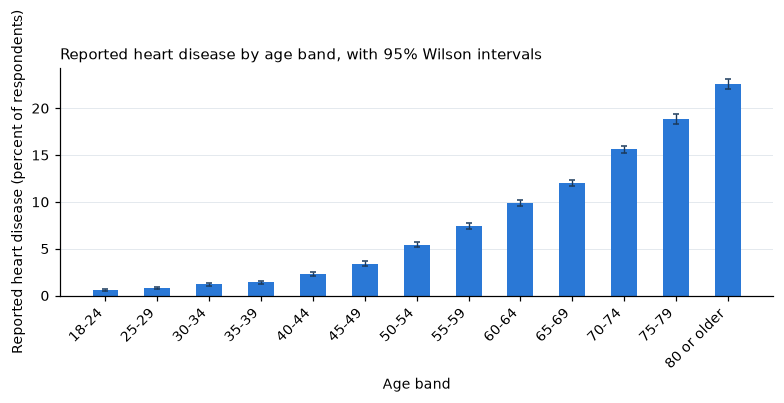

In [6]:
fig, ax = plt.subplots(figsize=(7.2, 3.4))

x = np.arange(len(age_df))
p = age_df["prevalence"].to_numpy() * 100
err = np.vstack([p - age_df["lo"].to_numpy() * 100, age_df["hi"].to_numpy() * 100 - p])

ax.bar(x, p, width=0.5, color=SERIES_BLUE)
ax.errorbar(x, p, yerr=err, fmt="none", ecolor=INK, elinewidth=0.9, capsize=2)
ax.set_xticks(x, age_df["age band"], rotation=45, ha="right")
ax.set_xlabel("Age band")
ax.set_ylabel("Reported heart disease (percent of respondents)")
ax.set_title("Reported heart disease by age band, with 95% Wilson intervals")
ax.grid(axis="x", visible=False)
plt.show()

The gradient is steep and monotone across all 13 bands. Prevalence runs from 0.6 percent
among respondents aged 18 to 24 to 22.6 percent among those aged 80 or older, a ratio of
about 37. The intervals are narrow enough that the ordering is not in doubt in this
sample.

What this cannot mean. It does not say that ageing causes heart disease in an individual.
It is a cross section: the 80 year olds in the file are a different set of people from
the 20 year olds, born 60 years apart, and everyone who died of heart disease before
2020 is absent from a survey of living respondents. Survivorship alone can bend the top
of this curve in either direction.

The reason this section comes first is that age is the spine of everything after it. Any
factor that is more common among older respondents will look like a heart disease factor
until age is held fixed.

## 3. Crude factor gaps

**The question.** For each candidate factor, how far apart are the exposed and unexposed
groups when nothing at all is held fixed?

This is the comparison most readers make by eye, and it is the one that is most often
mistaken for an effect. The ratio below is a crude prevalence ratio: the proportion
reporting heart disease among the exposed divided by the proportion among the unexposed,
with a log interval around it. The factor definitions, including which levels count as
exposed, live in `pipeline.constants.FACTORS`, and the helper that builds each row is
the same one that writes `prevalence_by_factor.json` for the site.

In [7]:
from pipeline.constants import FACTORS
from pipeline.prevalence import _factor_entry  # the helper behind prevalence_by_factor.json

entries = [_factor_entry(df, f) for f in FACTORS]
entries.sort(key=lambda e: e["ratio"] if e["ratio"] is not None else float("-inf"), reverse=True)

factor_df = pd.DataFrame(
    [
        {
            "factor": e["label"],
            "exposed group": e["exposed"]["label"],
            "n exposed": e["exposed"]["n"],
            "prevalence exposed": e["exposed"]["p"],
            "n unexposed": e["unexposed"]["n"],
            "prevalence unexposed": e["unexposed"]["p"],
            "ratio": e["ratio"],
            "lo": e["ratio_lo"],
            "hi": e["ratio_hi"],
        }
        for e in entries
    ]
)

print("crude prevalence ratios, nothing held fixed, ordered by ratio")
factor_df.round({"prevalence exposed": 4, "prevalence unexposed": 4, "ratio": 3, "lo": 3, "hi": 3})

crude prevalence ratios, nothing held fixed, ordered by ratio


,factor,exposed group,n exposed,prevalence exposed,n unexposed,prevalence unexposed,ratio,lo,hi
0,Fair or poor self-rated health,adults rating their health fair or poor,45966,0.2379,180700,0.0381,6.247,6.072,6.426
1,Stroke history,adults with a prior stroke,12069,0.3637,307726,0.0747,4.869,4.741,5.001
2,Kidney disease,adults with kidney disease,11779,0.2933,308016,0.0777,3.777,3.664,3.895
3,Serious difficulty walking,adults with serious difficulty walking,44410,0.2258,275385,0.0630,3.585,3.505,3.666
4,Diabetes,adults with diabetes,40802,0.2195,269653,0.0650,3.379,3.301,3.458
5,Skin cancer,adults with skin cancer,29819,0.1670,289976,0.0772,2.163,2.102,2.225
6,Smoking (100+ cigarettes ever),smokers,131908,0.1216,187887,0.0603,2.015,1.969,2.062
7,No physical activity,inactive adults,71838,0.1376,247957,0.0705,1.951,1.906,1.997
8,Short sleep (under 6 hours),short sleepers,30265,0.1237,164472,0.0715,1.732,1.673,1.793
9,Obesity (BMI 30 or more),adults with obesity,102842,0.1038,97331,0.0648,1.601,1.554,1.649


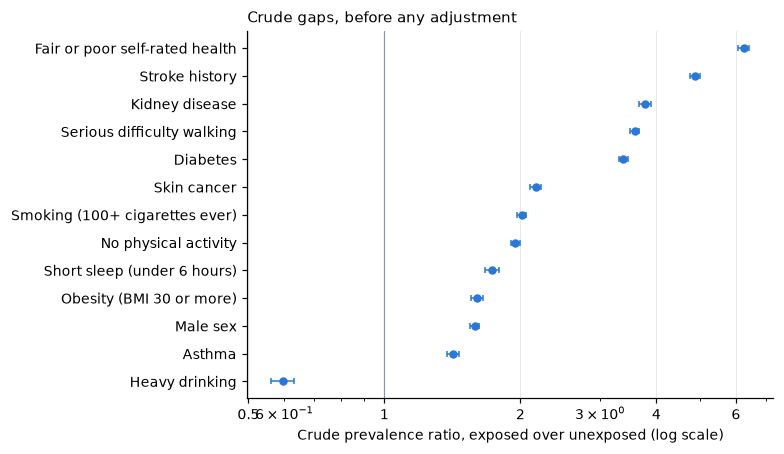

In [8]:
plot_df = factor_df.iloc[::-1].reset_index(drop=True)
y = np.arange(len(plot_df))

fig, ax = plt.subplots(figsize=(7.2, 4.2))
ax.errorbar(
    plot_df["ratio"],
    y,
    xerr=np.vstack([plot_df["ratio"] - plot_df["lo"], plot_df["hi"] - plot_df["ratio"]]),
    fmt="o",
    markersize=4.5,
    color=SERIES_BLUE,
    ecolor=SERIES_BLUE,
    elinewidth=1.0,
    capsize=2,
)
ax.axvline(1.0, color="#8a97a6", linewidth=0.8)
ax.set_yticks(y, plot_df["factor"])
ax.set_xscale("log")
ax.set_xticks([0.5, 1, 2, 4, 6], ["0.5", "1", "2", "4", "6"])
ax.set_xlabel("Crude prevalence ratio, exposed over unexposed (log scale)")
ax.set_title("Crude gaps, before any adjustment")
ax.grid(axis="y", visible=False)
plt.show()

Two groups of factors sit in this chart, and they are not the same kind of thing.

Stroke history, difficulty walking, fair or poor self rated health, diabetes and kidney
disease produce the widest crude gaps. Some of those are plausible upstream conditions.
Others are almost certainly downstream: a person who already has heart disease is more
likely to rate their health poorly and to report difficulty walking because of it.
Section 5 separates the two.

Smoking and physical inactivity are the two behavioural factors that a reader is most
likely to act on, and both show crude ratios around two. That is the claim worth
testing, because both smoking history and inactivity are also much more common among
older respondents. The next section holds age fixed without fitting anything.

## 4. The same gaps inside each age band

**The question.** If the crude gaps in section 3 are partly an age chart in disguise, how
much of each gap survives when the comparison is made only between people of the same
age?

This is stratification, not modelling. Within each of the 13 age bands the exposed and
unexposed prevalences are computed separately, so age cannot contribute to the
difference. Smoking and physical inactivity are shown because they are the two
behavioural factors a reader is most likely to act on, and because the model in section
5 goes on to treat them very differently.

In [9]:
from pipeline.prevalence import _factor_rows_by_age

factors_by_id = {f["id"]: f for f in FACTORS}
panels = {fid: _factor_rows_by_age(df, factors_by_id[fid]) for fid in ["smoking", "inactivity"]}


def band_frame(rows):
    return pd.DataFrame(
        [
            {
                "age band": r["age"],
                "n exposed": r["exposed"]["n"],
                "p exposed": r["exposed"]["p"],
                "n unexposed": r["unexposed"]["n"],
                "p unexposed": r["unexposed"]["p"],
                "ratio": (
                    round(r["exposed"]["p"] / r["unexposed"]["p"], 3)
                    if r["exposed"]["p"] and r["unexposed"]["p"]
                    else None
                ),
            }
            for r in rows
        ]
    )


for fid in panels:
    f = factors_by_id[fid]
    crude = next(e for e in entries if e["id"] == fid)
    print(f"=== {f['label']}: {f['exposed_label']} vs {f['unexposed_label']} ===")
    print(f"crude ratio over the whole sample: {crude['ratio']:.3f}")
    print(band_frame(panels[fid]).round({"p exposed": 4, "p unexposed": 4}).to_string(index=False))
    print()

=== Smoking (100+ cigarettes ever): smokers vs non-smokers ===
crude ratio over the whole sample: 2.015
   age band  n exposed  p exposed  n unexposed  p unexposed  ratio
      18-24       3284     0.0097        17780       0.0055  1.768
      25-29       5154     0.0114        11801       0.0063  1.825
      30-34       7172     0.0185        11581       0.0080  2.309
      35-39       8642     0.0211        11908       0.0096  2.200
      40-44       9081     0.0351        11925       0.0140  2.508
      45-49       8725     0.0533        13066       0.0214  2.496
      50-54       9973     0.0835        15409       0.0357  2.340
      55-59      12672     0.1079        17085       0.0489  2.207
      60-64      15436     0.1321        18250       0.0706  1.872
      65-69      15563     0.1577        18588       0.0886  1.781
      70-74      14925     0.1990        16140       0.1163  1.711
      75-79      10754     0.2256        10728       0.1513  1.491
80 or older      10527   

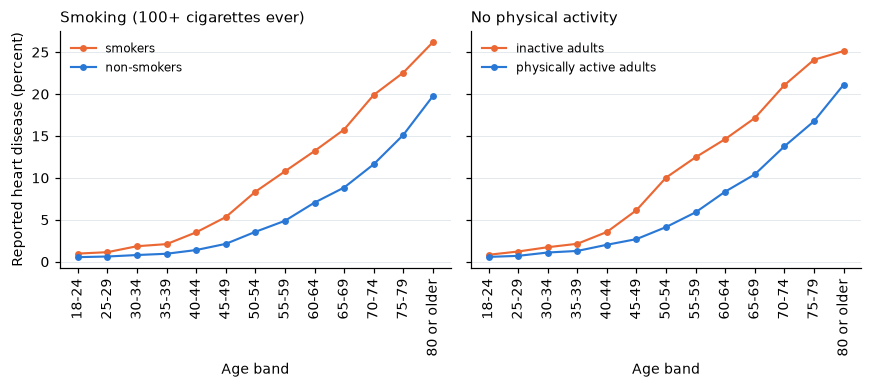

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(8.0, 3.6), sharey=True)

for ax, fid in zip(axes, ["smoking", "inactivity"]):
    f = factors_by_id[fid]
    frame = band_frame(panels[fid])
    x = np.arange(len(frame))
    ax.plot(
        x, frame["p exposed"] * 100, "-o", markersize=3.5, linewidth=1.4,
        color=SERIES_ORANGE, label=f["exposed_label"],
    )
    ax.plot(
        x, frame["p unexposed"] * 100, "-o", markersize=3.5, linewidth=1.4,
        color=SERIES_BLUE, label=f["unexposed_label"],
    )
    ax.set_xticks(x, frame["age band"], rotation=90)
    ax.set_title(f["label"])
    ax.set_xlabel("Age band")
    ax.grid(axis="x", visible=False)
    ax.legend(loc="upper left", fontsize=8)

axes[0].set_ylabel("Reported heart disease (percent)")
plt.show()

Both gaps survive stratification. The exposed line sits above the unexposed line in all
13 age bands for both factors, so neither crude ratio is purely an age artefact.

What changes across the lifespan is the size of the ratio. Smokers are about two and a
half times as likely as non smokers to report heart disease in the bands from 40 to 55,
and about 1.3 times as likely at 80 or older. Inactivity behaves the same way: the ratio
peaks near 2.4 in the early fifties and falls to about 1.2 in the oldest band. Both
ratios shrink at the top because the unexposed group's own prevalence climbs there.
Measured in percentage points rather than as a ratio, the gap is at its widest in the
seventies for both factors.

So holding age fixed by itself does not make either gap disappear. That is worth
noticing, because the model in section 5 does make one of them disappear, and the
difference between the two results is the whole of the next section.

What this cannot mean. Holding age fixed does not hold anything else fixed. Smokers in
the same age band still differ from non smokers in body mass, diabetes, sex and much
else that this file does record, and in income, education and insurance, which it does
not. The next section holds the recorded variables fixed simultaneously.

## 5. Two logistic models

**The question.** When all of the recorded upstream characteristics are held fixed at
once, which factors still show a gap, and how large is it?

Two nested logistic regressions are fitted on the same 319,795 rows (decision S3).

* **primary** holds age band, sex, BMI class, smoking, heavy drinking, diabetes, stroke
  history, kidney disease, asthma and skin cancer. These are upstream or structural
  characteristics. This is the model the site's estimator panel evaluates in the browser.
* **full** adds physical activity, difficulty walking and self rated general health.

The split is deliberate and it is the most important statistical decision in the project.
Self rated general health and difficulty walking are plausibly **consequences** of heart
disease rather than causes of it. Putting them in the same table as smoking and inviting
a reader to compare the rows is the Table 2 fallacy: only one coefficient in an adjusted
model can be read as an adjusted association for the exposure of interest, and covariates
that sit on the causal path between the exposure and the outcome will absorb part of the
association we are trying to see. So the downstream three are fitted in a separate model
and tagged `group: "downstream"`, and the site shows them in a separate panel labelled as
markers rather than causes.

Other decisions visible in the output below. Reference levels are pinned rather than left
to alphabetical order (S4). BMI enters as five WHO classes and never also as a continuous
term (S5). Convergence is asserted and the build fails if the optimiser did not converge,
any level whose thinnest two by two cell is under 10 is flagged `unstable`, and the
largest variance inflation factor is recorded (S6). Average marginal effects are reported
alongside the odds ratios, because a percentage point difference is what most readers
actually want (S7).

In [11]:
from pipeline.models import FULL_COVS, PRIMARY_COVS, fit_models

odds_ratios, estimator = fit_models(df)  # about ten seconds per model
primary = odds_ratios["models"]["primary"]
full = odds_ratios["models"]["full"]

print("primary covariates:", PRIMARY_COVS)
print("full covariates   :", FULL_COVS)
print()
print(
    pd.DataFrame(
        [
            {
                "model": name,
                "n_obs": m["n_obs"],
                "n_events": m["n_events"],
                "converged": m["converged"],
                "df_model": m["df_model"],
                "pseudo R2 (McFadden)": m["pseudo_r2_mcfadden"],
                "max VIF": m["max_vif"],
                "unstable terms": sum(t["unstable"] for t in m["terms"]),
            }
            for name, m in [("primary", primary), ("full", full)]
        ]
    ).to_string(index=False)
)

primary covariates: ['AgeCategory', 'Sex', 'BMIClass', 'Smoking', 'AlcoholDrinking', 'Diabetic', 'Stroke', 'KidneyDisease', 'Asthma', 'SkinCancer']
full covariates   : ['AgeCategory', 'Sex', 'BMIClass', 'Smoking', 'AlcoholDrinking', 'Diabetic', 'Stroke', 'KidneyDisease', 'Asthma', 'SkinCancer', 'PhysicalActivity', 'DiffWalking', 'GenHealth']

  model  n_obs  n_events  converged  df_model  pseudo R2 (McFadden)  max VIF  unstable terms
primary 319795     27373       True        26                0.1873     2.48               0
   full 319795     27373       True        32                0.2221     2.49               0


Both models converged, and the largest variance inflation factor is under 2.5 in each,
so no coefficient below is a collinearity artefact. No level is flagged unstable, which
means every level has at least 10 respondents in each cell of its level by outcome table.
McFadden pseudo R squared is not a proportion of variance explained and should not be
read as one; it is reported only so that the two nested models can be compared with each
other.

In [12]:
def term_frame(model, *, group=None):
    rows = []
    for t in model["terms"]:
        if group is not None and t["group"] != group:
            continue
        rows.append(
            {
                "variable": t["variable"],
                "level": t["label"],
                "n": t["n_level"],
                "events": t["events_level"],
                "OR": t["or"],
                "lo": t["lo"],
                "hi": t["hi"],
                "AME (pp)": None if t["ame"] is None else round(t["ame"] * 100, 2),
                "p": t["p_value"],
                "ref": t["is_reference"],
            }
        )
    return pd.DataFrame(rows)


primary_terms = term_frame(primary)
print(f"primary model: {len(primary_terms)} rows, of which {int(primary_terms['ref'].sum())} are reference levels")
print("OR is the odds ratio against the reference level of the same variable.")
print("AME is the average marginal effect in percentage points of prevalence.")
primary_terms

primary model: 36 rows, of which 10 are reference levels
OR is the odds ratio against the reference level of the same variable.
AME is the average marginal effect in percentage points of prevalence.


,variable,level,n,events,OR,lo,hi,AME (pp),p,ref
0,AgeCategory,Age 18-24,21064,130,1.0000,NaN,NaN,NaN,NaN,True
1,AgeCategory,Age 25-29,16955,133,1.1326,0.8882,1.4442,0.84,3.150000e-01,False
2,AgeCategory,Age 30-34,18753,226,1.6462,1.3247,2.0459,3.35,6.940000e-06,False
3,AgeCategory,Age 35-39,20550,296,1.8832,1.5296,2.3186,4.25,2.440000e-09,False
4,AgeCategory,Age 40-44,21006,486,2.8837,2.3716,3.5065,7.12,2.520000e-26,False
5,AgeCategory,Age 45-49,21791,744,4.1104,3.4042,4.9629,9.50,6.600000e-49,False
6,AgeCategory,Age 50-54,25382,1383,6.4488,5.3759,7.7357,12.52,1.170000e-89,False
7,AgeCategory,Age 55-59,29757,2202,8.4526,7.0670,10.1100,14.34,9.610000e-121,False
8,AgeCategory,Age 60-64,33686,3327,11.1122,9.3062,13.2687,16.18,5.240000e-156,False
9,AgeCategory,Age 65-69,34151,4101,13.5833,11.3819,16.2105,17.53,7.140000e-184,False


Reading the table. Age dominates: relative to respondents aged 18 to 24, the odds for
respondents aged 80 or older are about 31 times higher, and the average marginal effect
is about 23 percentage points. Nothing else in the file comes close.

Among the behaviours and conditions, four survive adjustment with a wide margin:

| factor | adjusted odds ratio, primary model |
|---|---|
| stroke history | about 3.75 |
| kidney disease | about 2.36 |
| diabetes | about 2.07 |
| smoking | about 1.69 |

Smoking falls from a crude prevalence ratio of about 2.0 to an adjusted odds ratio of
about 1.69, so part of the crude gap was age and the rest of the adjustment set, and part
of it was not.

Heavy drinking has an adjusted odds ratio below 1. That is not evidence that heavy
drinking protects anyone. In a cross section of living survey respondents, people who
have been told they have heart disease are advised to stop drinking, and heavy drinkers
who die are not surveyed. This is the clearest example in the file of an association that
cannot be read forwards in time.

In [13]:
def term(model, variable, level):
    for t in model["terms"]:
        if t["variable"] == variable and t["level"] == level:
            return t
    raise KeyError((variable, level))


compare = pd.DataFrame(
    [
        {
            "factor": label,
            "crude ratio": next(e["ratio"] for e in entries if e["id"] == fid),
            "primary OR": term(primary, var, lvl)["or"],
            "full OR": term(full, var, lvl)["or"],
        }
        for fid, label, var, lvl in [
            ("smoking", "Smoking", "Smoking", "Yes"),
            ("stroke", "Stroke history", "Stroke", "Yes"),
            ("diabetes", "Diabetes", "Diabetic", "Yes"),
            ("kidney", "Kidney disease", "KidneyDisease", "Yes"),
            ("obesity", "Obese class II or III", "BMIClass", "Obese II+"),
            ("sex", "Male", "Sex", "Male"),
        ]
    ]
)

activity = term(full, "PhysicalActivity", "Yes")
inactivity_or = 1 / activity["or"]
inactivity_lo = 1 / activity["hi"]
inactivity_hi = 1 / activity["lo"]
crude_inactivity = next(e["ratio"] for e in entries if e["id"] == "inactivity")

print("crude gap, adjusted for upstream covariates, then adjusted for the downstream three")
print(compare.round(3).to_string(index=False))
print()
print("physical inactivity, the factor that does not survive adjustment")
print(f"  crude prevalence ratio, inactive over active : {crude_inactivity:.3f}")
print(f"  adjusted odds ratio, inactive over active    : {inactivity_or:.3f}"
      f"  (95% CI {inactivity_lo:.3f} to {inactivity_hi:.3f})")

crude gap, adjusted for upstream covariates, then adjusted for the downstream three
               factor  crude ratio  primary OR  full OR
              Smoking        2.015       1.692    1.453
       Stroke history        4.869       3.750    2.842
             Diabetes        3.379       2.070    1.582
       Kidney disease        3.777       2.355    1.769
Obese class II or III        1.601       1.554    1.185
                 Male        1.586       1.884    2.003

physical inactivity, the factor that does not survive adjustment
  crude prevalence ratio, inactive over active : 1.951
  adjusted odds ratio, inactive over active    : 0.984  (95% CI 0.954 to 1.016)


The physical activity result is the one finding in this notebook that reverses a common
expectation. The crude prevalence ratio is about 1.95: respondents who report no physical
activity are roughly twice as likely to report heart disease. Once age, sex, BMI class,
smoking, diabetes, stroke, kidney disease, asthma, skin cancer, difficulty walking and
self rated health are held fixed, the adjusted odds ratio for inactivity is about **0.98**,
with an interval that comfortably contains 1. The gap disappears.

The honest reading is not that activity does not matter. Section 4 showed that age alone
does not account for the inactivity gap, so this is not the age story again. It is that
in this file the gap is almost entirely accounted for by who the inactive respondents
are on the other covariates: they are much more likely to report serious difficulty
walking, they rate their own health worse, and they are older and more often diabetic.
Difficulty walking and poor self rated health are themselves plausible
consequences of heart disease, so adjusting for them can remove a real association along
with a confounded one. A cross sectional survey cannot separate those two explanations,
and the site says so rather than picking the flattering one.

In [14]:
downstream = term_frame(full, group="downstream")
print("full model, downstream terms only: markers, not causes")
print("These are shown separately because they are plausibly consequences of heart disease.")
downstream

full model, downstream terms only: markers, not causes
These are shown separately because they are plausibly consequences of heart disease.


,variable,level,n,events,OR,lo,hi,AME (pp),p,ref
0,PhysicalActivity,No physical activity in past 30 days,71838,9884,1.0000,NaN,NaN,NaN,NaN,True
1,PhysicalActivity,Physically active in past 30 days,247957,17489,1.0160,0.9847,1.0484,0.10,3.200000e-01,False
2,DiffWalking,No difficulty walking,275385,17345,1.0000,NaN,NaN,NaN,NaN,True
3,DiffWalking,Serious difficulty walking,44410,10028,1.2697,1.2264,1.3145,1.55,1.680000e-41,False
4,GenHealth,Self-rated health: excellent,66842,1500,1.0000,NaN,NaN,NaN,NaN,True
5,GenHealth,Self-rated health: very good,113858,5381,1.6081,1.5152,1.7068,3.08,3.860000e-55,False
6,GenHealth,Self-rated health: good,93129,9558,2.8512,2.6908,3.0212,6.79,1.760000e-275,False
7,GenHealth,Self-rated health: fair,34677,7084,4.7187,4.4317,5.0244,10.05,0.000000e+00,False
8,GenHealth,Self-rated health: poor,11289,3850,7.4062,6.8822,7.9700,12.97,0.000000e+00,False


The downstream terms are large. Self rated poor health carries an odds ratio around 7.4
against excellent health, and difficulty walking around 1.27 once the rest of the full
model is held fixed. Both are best read as markers that travel with the condition rather
than as anything a reader could act on. They are useful for a different question, namely
how much of the upstream associations they absorb, which is the third column of the
comparison table above: smoking falls from 1.69 to 1.45 and stroke history from 3.75 to
2.84 when they enter.

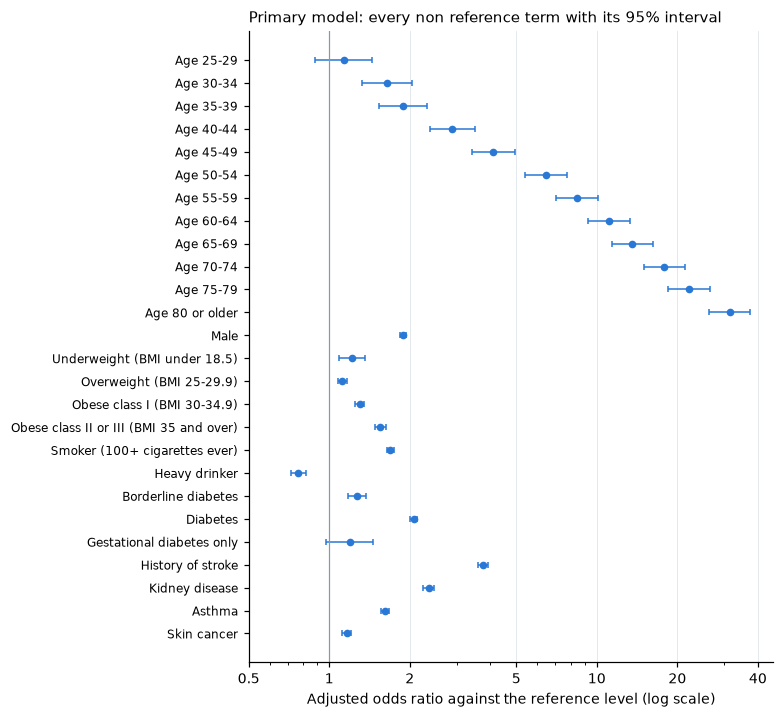

In [15]:
forest = primary_terms[~primary_terms["ref"]].iloc[::-1].reset_index(drop=True)
y = np.arange(len(forest))

fig, ax = plt.subplots(figsize=(7.2, 6.6))
ax.errorbar(
    forest["OR"],
    y,
    xerr=np.vstack([forest["OR"] - forest["lo"], forest["hi"] - forest["OR"]]),
    fmt="o",
    markersize=4,
    color=SERIES_BLUE,
    ecolor=SERIES_BLUE,
    elinewidth=1.0,
    capsize=2,
)
ax.axvline(1.0, color="#8a97a6", linewidth=0.8)
ax.set_yticks(y, forest["level"], fontsize=8)
ax.set_xscale("log")
ax.set_xticks([0.5, 1, 2, 5, 10, 20, 40], ["0.5", "1", "2", "5", "10", "20", "40"])
ax.set_xlabel("Adjusted odds ratio against the reference level (log scale)")
ax.set_title("Primary model: every non reference term with its 95% interval")
ax.grid(axis="y", visible=False)
plt.show()

## 6. Interactions: body mass against sleep

**The question.** Do two factors that each show a modest association combine into
something larger than either alone, or do they simply add up?

The model in section 5 is additive on the log odds scale; it cannot answer this. A
crosstab can, at the cost of thin cells. The table below is prevalence within every
combination of BMI class and sleep band.

Two rules apply to every cell. Crosstabs are built on ordered categoricals with
`observed=False`, so a combination with zero respondents appears as an explicit zero row
rather than silently shifting the cells next to it (decision S9). And any cell with fewer
than 30 respondents gets no estimate at all, while any cell under 300 is flagged as thin
(decision S2), because a two person cell with one event would otherwise plot as a
confident 50 percent.

In [16]:
heat = prevalence_table(df, ["BMIClass", "SleepBand"], file_id="bmi_sleep_heatmap")
heat_df = pd.DataFrame(
    [
        {
            "BMI class": r["key"][0],
            "sleep band": r["key"][1],
            "n": r["n"],
            "events": r["events"],
            "prevalence": r["p"],
            "small_n": r["small_n"],
            "suppressed": r["suppressed"],
        }
        for r in heat["rows"]
    ]
)

bmi_order = list(df["BMIClass"].cat.categories)
sleep_order = list(df["SleepBand"].cat.categories)

counts = heat_df.pivot(index="BMI class", columns="sleep band", values="n")
counts = counts.reindex(index=bmi_order, columns=sleep_order)
prev = heat_df.pivot(index="BMI class", columns="sleep band", values="prevalence")
prev = prev.reindex(index=bmi_order, columns=sleep_order)

print("respondents per cell")
print(counts.to_string())
print()
print(f"cells suppressed for n < 30 : {int(heat_df['suppressed'].sum())}")
print(f"cells flagged thin, n < 300 : {int(heat_df['small_n'].sum())}")
print()
print("prevalence per cell, percent")
(prev * 100).round(2)

respondents per cell
sleep band   Under 6h   6-7h   8-9h  10h or more
BMI class                                       
Underweight       659   2304   1860          287
Normal           7722  49323  37061         3225
Overweight       9744  59862  41251         3655
Obese I          6402  31978  20656         2309
Obese II+        5738  21005  12815         1939

cells suppressed for n < 30 : 0
cells flagged thin, n < 300 : 1

prevalence per cell, percent


sleep band,Under 6h,6-7h,8-9h,10h or more
BMI class,,,,
Underweight,12.29,6.21,7.31,14.29
Normal,10.08,5.30,6.72,13.15
Overweight,12.24,7.31,9.30,16.03
Obese I,13.78,8.41,10.44,18.71
Obese II+,14.13,9.19,11.17,17.48


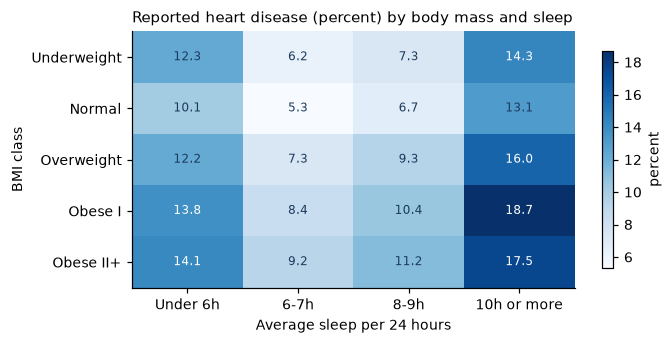

In [17]:
values = prev.to_numpy(dtype=float) * 100

fig, ax = plt.subplots(figsize=(6.4, 3.2))
im = ax.imshow(values, cmap="Blues", aspect="auto", vmin=np.nanmin(values), vmax=np.nanmax(values))

ax.set_xticks(np.arange(len(sleep_order)), sleep_order)
ax.set_yticks(np.arange(len(bmi_order)), bmi_order)
ax.set_xlabel("Average sleep per 24 hours")
ax.set_ylabel("BMI class")
ax.set_title("Reported heart disease (percent) by body mass and sleep")
ax.grid(False)

threshold = np.nanmin(values) + 0.6 * (np.nanmax(values) - np.nanmin(values))
for i in range(values.shape[0]):
    for j in range(values.shape[1]):
        v = values[i, j]
        if np.isnan(v):
            ax.text(j, i, "n < 30", ha="center", va="center", fontsize=7, color="#6b7784")
        else:
            ax.text(j, i, f"{v:.1f}", ha="center", va="center", fontsize=8,
                    color="white" if v > threshold else INK)

fig.colorbar(im, ax=ax, shrink=0.85, label="percent")
plt.show()

Prevalence rises towards the edges of the sleep axis. Respondents who report under six
hours of sleep, and those who report ten or more, both sit above the six to seven and
eight to nine bands within the same BMI class. The pattern is a U, not a slope, and it
appears in every one of the five BMI classes.

None of this is adjusted for anything, and age is doing work in every cell, because older
respondents are over represented in both the long sleep and the high BMI cells. Read the
table as a description of who is in each cell, not as an interaction effect. A ten hour
sleeper with a high BMI in this file is, more often than not, an older respondent in poor
health, and the cell prevalence reflects that before it reflects sleep.

## 7. Race, crude against age standardised

**The question.** How does reported prevalence differ by the race category recorded in
the file, and how much of the crude difference is the different age structure of each
group?

Race is analysed descriptively here and is deliberately **not** a covariate in either
logistic model (decision D4). The reason is what the file is missing. There is no income,
no education, no health insurance, no geography and no measure of access to care. A race
coefficient estimated with those confounders absent would be an invitation to read a
social gradient as something intrinsic, and the file cannot support that reading and
cannot correct it either.

What can be done honestly is to remove the one confounder the file does record. The
subsamples have very different age structures: the White subsample is much older than the
Hispanic one, so part of any crude gap is an age gap wearing a race label. Direct
standardisation reweights each group's age specific rates to one shared age distribution.

The standard population is the pooled sample's own age distribution (decision S8). No
external denominator exists for this extract, and the 2000 US standard population's bands
do not line up with the 13 BRFSS bands. The weights are printed below and are published
in `race_prevalence.json`, so the standardisation can be checked rather than trusted.
Intervals on the standardised rates use the Fay and Feuer gamma method, which behaves
correctly when some age bands within a group are thin, where a normal interval would not.

In [18]:
from pipeline.constants import AGE_BANDS
from pipeline.standardise import race_prevalence, standard_population

weights = standard_population(df)
weight_df = pd.DataFrame({"age band": AGE_BANDS, "weight": weights})

print("standard population: the pooled sample's own age distribution")
print(weight_df.assign(weight=weight_df["weight"].round(6)).to_string(index=False))
print()
print(f"weights sum to {weights.sum():.12f}")

standard population: the pooled sample's own age distribution
   age band   weight
      18-24 0.065867
      25-29 0.053018
      30-34 0.058641
      35-39 0.064260
      40-44 0.065686
      45-49 0.068141
      50-54 0.079370
      55-59 0.093050
      60-64 0.105336
      65-69 0.106790
      70-74 0.097140
      75-79 0.067174
80 or older 0.075527

weights sum to 1.000000000000


In [19]:
rp = race_prevalence(df)

race_df = pd.DataFrame(
    [
        {
            "race": r["key"][0],
            "n": r["n"],
            "events": r["events"],
            "crude": r["crude"],
            "crude lo": r["crude_lo"],
            "crude hi": r["crude_hi"],
            "standardised": r["std"],
            "std lo": r["std_lo"],
            "std hi": r["std_hi"],
            "thinnest age band": r["min_band_n"],
            "small_n": r["small_n"],
        }
        for r in rp["rows"]
    ]
)

print("intervals:", rp["ci"])
print()
race_df.round(
    {"crude": 4, "crude lo": 4, "crude hi": 4, "standardised": 4, "std lo": 4, "std hi": 4}
)

intervals: {'crude': 'wilson', 'standardised': 'fay-feuer gamma', 'level': 0.95}



,race,n,events,crude,crude lo,crude hi,standardised,std lo,std hi,thinnest age band,small_n
0,White,245212,22507,0.0918,0.0906,0.0929,0.0846,0.0835,0.0857,10892,False
1,Black,22939,1729,0.0754,0.0720,0.0789,0.0839,0.0799,0.0881,1074,False
2,Hispanic,27446,1443,0.0526,0.0500,0.0553,0.0834,0.0787,0.0884,669,False
3,Asian,8068,266,0.0330,0.0293,0.0371,0.0514,0.0450,0.0584,248,False
4,American Indian/Alaskan Native,5202,542,0.1042,0.0962,0.1128,0.1251,0.1142,0.1369,176,False
5,Other,10928,886,0.0811,0.0761,0.0863,0.1030,0.0961,0.1102,424,False


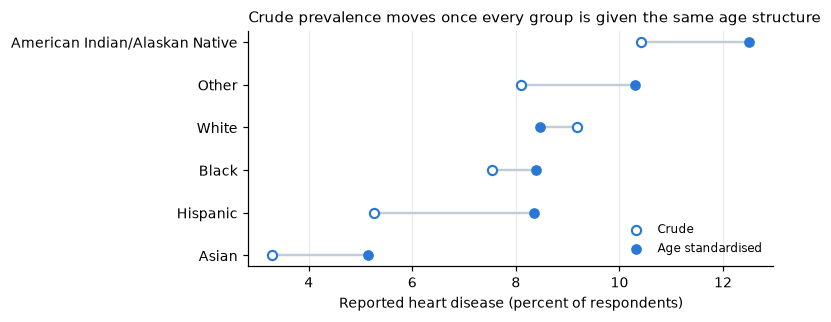

In [20]:
order = race_df.sort_values("standardised").reset_index(drop=True)
y = np.arange(len(order))

fig, ax = plt.subplots(figsize=(7.2, 3.0))
for yi, crude, std in zip(y, order["crude"] * 100, order["standardised"] * 100):
    ax.plot([crude, std], [yi, yi], color="#c3ccd6", linewidth=1.6, zorder=1)
ax.scatter(order["crude"] * 100, y, s=36, facecolors="white", edgecolors=SERIES_BLUE,
           linewidths=1.4, zorder=2, label="Crude")
ax.scatter(order["standardised"] * 100, y, s=36, color=SERIES_BLUE, zorder=3,
           label="Age standardised")

ax.set_yticks(y, order["race"])
ax.set_xlabel("Reported heart disease (percent of respondents)")
ax.set_title("Crude prevalence moves once every group is given the same age structure")
ax.grid(axis="y", visible=False)
ax.legend(loc="lower right", fontsize=8)
plt.show()

Standardisation moves the picture substantially. The crude spread runs from about 3.3
percent among Asian respondents to about 10.4 percent among American Indian and Alaskan
Native respondents. After every group is given the same age structure, the White, Black
and Hispanic rates land within a few tenths of a percentage point of one another near
8.4 percent, which means most of the crude Hispanic to White gap was an age gap. The
American Indian and Alaskan Native rate rises rather than falls, to about 12.5 percent,
because that subsample is younger than the pooled sample, so its crude rate understated
it.

What this cannot mean. Age is the only confounder that has been removed, because it is
the only one the file records. The remaining differences are consistent with differences
in income, education, insurance coverage, geography, access to diagnosis, and with the
fact that a heart disease diagnosis has to be received before it can be reported. A group
with worse access to care can report less heart disease while having more of it. The
categories themselves are the six the survey offered, and "Other" is not a population.

## 8. What this file cannot tell you

Every limit below is a property of the data, not a caveat added for modesty.

**A third party's extract, not the CDC release.** This file is a Kaggle extract of the
CDC Behavioral Risk Factor Surveillance System 2020 annual survey, prepared by kamilpytlak.
It reduces the 401,958 respondents in the 2020 release to the 319,795 rows analysed here by
dropping rows with a missing value in the columns kept, a cleaning step performed before
the file reached this project and not repeated here. Section 1 has the sha256 and the row
count for anyone who wants to check the numbers against the same bytes.

**No survey design information.** BRFSS is stratified, clustered and weighted. This
extract carries none of that. Every proportion above is an unweighted sample proportion,
not a national estimate, and every Wilson interval treats 319,795 rows as a simple random
sample. Real survey intervals on BRFSS are wider, typically by a design effect somewhere
between 1.5 and 2.5. The second cell below shows what that would do to the headline
interval. No such correction is applied anywhere in the project, because the information
needed to compute the real one is not in the file; the table is an illustration of the
direction and rough size of the error.

**No confounders that matter.** There is no income, education, insurance, geography or
access to care variable. That is why race is descriptive only (decision D4), and it is
also why every adjusted odds ratio in section 5 is adjusted for the recorded variables
alone.

**Self report throughout, including the outcome.** `HeartDisease` records whether a
respondent says they were told they had coronary heart disease or a myocardial
infarction. Undiagnosed disease is invisible, and a diagnosis requires contact with the
health system, so the outcome partly measures access to care.

**Cross sectional, so no time order.** Exposure and outcome were recorded in the same
interview. Reverse causation is available everywhere and is the likely explanation for
several results above, including heavy drinking and physical activity.

**Survivorship.** Everyone who died before 2020 is absent. In the oldest bands this
matters most.

**Duplicates kept.** 18,078 exact duplicate rows remain, for the reasons in section 1.
If any of them are genuinely one respondent counted twice, the effective sample is
slightly smaller than 319,795 and the intervals are slightly narrower than they should
be, which points the same way as the design effect above.

**Class imbalance is not a problem here.** 8.6 percent of rows are positive. That number
is often described as a class imbalance to be corrected with resampling or class weights.
No classifier is fitted anywhere in this project, so there is nothing to correct: the
positive rate is the quantity being estimated. Resampling would change the estimate
rather than improve it. The only place the rate matters is the width of the intervals in
thin subgroups (decision S10).

In [21]:
missing_variables = [
    "Income",
    "Education",
    "Health insurance or coverage",
    "State, region or any geography",
    "BRFSS design weight (_LLCPWT)",
    "Stratum and primary sampling unit",
    "Respondent identifier",
    "Interview date",
]

print(f"columns in the file: {len(raw.columns)}")
print("anything that looks like a weight or a design variable:")
print("  ", [c for c in raw.columns if "weight" in c.lower() or c.startswith("_")])
print()
print("recorded by BRFSS but absent from this extract:")
for name in missing_variables:
    print("   not in the file:", name)
print()
print(f"positive outcome rate: {df['hd'].mean():.4f}  ({int(df['hd'].sum())} of {len(df)} rows)")
print("no classifier is fitted in this project, so the positive rate needs no correction")

columns in the file: 18
anything that looks like a weight or a design variable:
   []

recorded by BRFSS but absent from this extract:
   not in the file: Income
   not in the file: Education
   not in the file: Health insurance or coverage
   not in the file: State, region or any geography
   not in the file: BRFSS design weight (_LLCPWT)
   not in the file: Stratum and primary sampling unit
   not in the file: Respondent identifier
   not in the file: Interview date

positive outcome rate: 0.0856  (27373 of 319795 rows)
no classifier is fitted in this project, so the positive rate needs no correction


In [22]:
from pipeline.stats import wilson

rows = []
for deff in (1.0, 1.5, 2.0, 2.5):
    n_eff = int(round(overall["n"] / deff))
    events_eff = int(round(overall["events"] / deff))
    lo, hi = wilson(events_eff, n_eff)
    rows.append(
        {
            "assumed design effect": deff,
            "effective n": n_eff,
            "lo": round(lo, 5),
            "hi": round(hi, 5),
            "interval width (pp)": round((hi - lo) * 100, 3),
        }
    )

print("Illustration only. The published interval is the first row; the rest show how much")
print("wider it would be if the BRFSS design effect were known and applied.")
print("No design effect is applied anywhere in the pipeline.")
print()
pd.DataFrame(rows)

Illustration only. The published interval is the first row; the rest show how much
wider it would be if the BRFSS design effect were known and applied.
No design effect is applied anywhere in the pipeline.



,assumed design effect,effective n,lo,hi,interval width (pp)
0,1.0,319795,0.08463,0.08657,0.194
1,1.5,213197,0.08442,0.08679,0.238
2,2.0,159898,0.08423,0.08697,0.274
3,2.5,127918,0.08407,0.08714,0.307


### What the notebook is for

The site states this argument in about two minutes of reading. This notebook is the
version that shows its work: the same functions, the same numbers, and the reasoning at
each step written out rather than compressed into a caption.

One sentence carries the whole thing. Most of what looks like a lifestyle gap in this
file is, in part, an age chart, and the honest job of the analysis is to say how much of
each gap is left once age and the rest of the recorded variables are held fixed, and to
be explicit about the gaps this file can never explain.